In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from operator import attrgetter
from datetime import datetime
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors

**Задание 1**

Необходимо рассчитать `Retention` по дням, начиная с даты регистрации игрока в игре.

Метрика `Retention` отвечает на вопрос: какая доля клиентов вернулась в продукт через определенный период после первого касания.

**A) Первичный анализ данных (EDA) и предобработка**

In [2]:
# датасет с информацией о времени регистрации игроков(в качетсве разделителя используем ;)
df_reg = pd.read_csv('../../shared/problem1-reg_data.csv', encoding='utf-8', sep=';')
df_reg.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [20]:
type(df_reg)

pandas.core.frame.DataFrame

In [3]:
# датасет с информацией о времени заходов пользователей в игру
df_visit = pd.read_csv('../../shared/problem1-auth_data.csv', encoding='utf-8', sep=';')
df_visit.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [4]:
# посмотрим на размеры датасетов
df_reg.shape

(1000000, 2)

In [5]:
df_visit.shape

(9601013, 2)

In [6]:
# проверим типы данных в датасетах
df_reg.dtypes

reg_ts    int64
uid       int64
dtype: object

In [7]:
df_visit.dtypes

auth_ts    int64
uid        int64
dtype: object

In [9]:
# проверим есть ли в данных пустые значения
df_reg.isna().sum()

reg_ts    0
uid       0
dtype: int64

In [10]:
df_visit.isna().sum()

auth_ts    0
uid        0
dtype: int64

In [11]:
# переведем время из секунд Unix в читаемый формат
df_reg['reg_ts'] = pd.to_datetime(df_reg['reg_ts'], unit='s')
df_reg['reg_ts'] = df_reg['reg_ts'].dt.strftime('%Y-%m-%d')
df_reg.head()

,reg_ts,uid
0,1998-11-18,1
1,1999-07-22,2
2,2000-01-13,3
3,2000-05-28,4
4,2000-09-16,5


In [24]:
df_reg.dtypes

reg_ts    object
uid        int64
dtype: object

In [12]:
df_visit['auth_ts'] = pd.to_datetime(df_visit['auth_ts'], unit='s')
df_visit['auth_ts'] = df_visit['auth_ts'].dt.strftime('%Y-%m-%d')
df_visit.head()

,auth_ts,uid
0,1998-11-18,1
1,1999-07-22,2
2,1999-07-25,2
3,1999-07-31,2
4,1999-08-05,2


In [13]:
# сделаем merge данных для дальнейшего анализа
df_main = df_reg.merge(df_visit, on='uid')
df_main.head()

,reg_ts,uid,auth_ts
0,1998-11-18,1,1998-11-18
1,1999-07-22,2,1999-07-22
2,1999-07-22,2,1999-07-25
3,1999-07-22,2,1999-07-31
4,1999-07-22,2,1999-08-05


Заметим, что **время первого визита в игру новых пользователей совпадает с датой регистрации**! Таким образом для когортного анализа можно использовать в качестве первого времени захода пользователя `дату регистрации`.

In [14]:
# Посмотрим на минимальные и максимальные даты заходов пользователей в игру
min_visit = df_main.auth_ts.min()
max_visit = df_main.auth_ts.max()
print(f"Дата самого первого захода в игру: {min_visit}")
print(f"Дата самого последнего захода в игру: {max_visit}")

Дата самого первого захода в игру: 1998-11-18
Дата самого последнего захода в игру: 2020-09-23


Вывод по полученным данным:

В полученном датасете большое количество данных за прошлые года, которые **утратили актуальность**. Для того, чтобы получить **свежие** показатели дневного `retention` будем рассматривать последний месяц датасета - **сентябрь 2020 года**.

**Б) Функция для подсчета данных по retention**

Функция будет принимать на вход `DataFrame` и дату `start_date`, с котороой ведется подсчет дневного retention, а на выходе выдавать `матрицу retention` по дневным когортам, прошедшим с указанной даты.

In [56]:
def get_retention_matrix(dataframe: pd.core.frame.DataFrame, start_date: str, reg_date: str , visit_date: str , user_id: str ):
    '''
    Функция принимает на вход Pandas Datafame, а так же строковые переменные: 
    start_date - дата в формате YYYY-MM-DD, начиная с которой рассчитывается Retention; 
    reg_date - название столбца с временем регистрации пользователя;
    visit_date - название столбца с временем заходов пользователей;
    user_id - название столбца с id пользователей;
    
    На выходе имеем матрицу Retention, подсчитанную по дням прошедшим с указанного start_date,
    а так же размер когорты по каждому из дней.
    '''
    # фильтруем пользователей по дате регистрации
    data_filter = dataframe[dataframe[reg_date] >= start_date]
    
    # подсчитаем разницу между датой захода и днем когорты
    # если имеем нулевую разницу, то получаем 0ую когорту
    data_filter[reg_date] = pd.to_datetime(data_filter[reg_date]).dt.to_period('D')
    data_filter[visit_date] = pd.to_datetime(data_filter[visit_date]).dt.to_period('D')
    data_filter['period_number_day'] = np.floor( (data_filter[visit_date] - data_filter[reg_date]).apply(attrgetter('n')) )
    
    # Рассчитаем количесвто пользователей для каждого дня отдельной когорты
    df_cohort = data_filter.groupby([reg_date, 'period_number_day']).agg(n_users=(user_id, 'nunique')).reset_index()
    
    # развернем полученную таблицу
    cohort_pivot = df_cohort.pivot_table(index=reg_date, columns='period_number_day', values='n_users')
    
    # рассчитываем размеры когорт (первый столбец таблицы)
    cohort_size = cohort_pivot.iloc[:, 0]
    
    # Вычисляем retention по строкам
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
    
    return retention_matrix, cohort_size

In [50]:
# Создаем матрицу дневного Retention за последний доступный месяц - сентябрь 2020
retention_2020_Sep, cohort_size_2020_Sep  = get_retention_matrix(dataframe=df_main, start_date="2020-09-01", reg_date='reg_ts', visit_date='auth_ts', user_id='uid')

/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [51]:
# посмотрим на полученную матрицу Retention
retention_2020_Sep

period_number_day,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0
reg_ts,,,,,,,,,,,,,,,,,,,,,
2020-09-01,1.0,0.020177,0.040984,0.042245,0.046028,0.064313,0.056116,0.064313,0.040984,0.054224,...,0.054855,0.042875,0.044136,0.043506,0.050441,0.041614,0.043506,0.035939,0.043506,0.015763
2020-09-02,1.0,0.025189,0.039043,0.046599,0.056675,0.062343,0.071159,0.062972,0.048489,0.040932,...,0.043451,0.049748,0.052897,0.041562,0.048489,0.039043,0.037154,0.046599,0.026448,NaN
2020-09-03,1.0,0.023256,0.054054,0.047140,0.065368,0.069767,0.085481,0.063482,0.054683,0.062854,...,0.059711,0.054683,0.053426,0.043997,0.048397,0.046512,0.054683,0.023884,NaN,NaN
2020-09-04,1.0,0.020088,0.036409,0.036409,0.051475,0.064030,0.072819,0.049592,0.053358,0.043315,...,0.055869,0.043942,0.045198,0.045198,0.042687,0.047709,0.026365,NaN,NaN,NaN
2020-09-05,1.0,0.027569,0.039474,0.046366,0.054511,0.058897,0.074561,0.048872,0.050752,0.054511,...,0.053885,0.045113,0.051378,0.044486,0.047619,0.025063,NaN,NaN,NaN,NaN
2020-09-06,1.0,0.031270,0.043152,0.054409,0.056285,0.058787,0.068168,0.060663,0.058161,0.055034,...,0.051907,0.055034,0.045654,0.048155,0.025641,NaN,NaN,NaN,NaN,NaN
2020-09-07,1.0,0.029357,0.042473,0.053716,0.050593,0.063710,0.073079,0.052467,0.041224,0.056215,...,0.050593,0.042473,0.050593,0.033729,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-08,1.0,0.017456,0.039277,0.039277,0.048628,0.076060,0.075436,0.066085,0.051746,0.051746,...,0.051746,0.047382,0.030549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-09,1.0,0.017424,0.032358,0.046671,0.057250,0.066584,0.057250,0.059116,0.043559,0.050404,...,0.048538,0.024269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
# Выведем размер когорты по каждому из дней
cohort_size_2020_Sep

reg_ts
2020-09-01    1586.0
2020-09-02    1588.0
2020-09-03    1591.0
2020-09-04    1593.0
2020-09-05    1596.0
2020-09-06    1599.0
2020-09-07    1601.0
2020-09-08    1604.0
2020-09-09    1607.0
2020-09-10    1609.0
2020-09-11    1612.0
2020-09-12    1614.0
2020-09-13    1618.0
2020-09-14    1619.0
2020-09-15    1623.0
2020-09-16    1625.0
2020-09-17    1628.0
2020-09-18    1630.0
2020-09-19    1634.0
2020-09-20    1636.0
2020-09-21    1638.0
2020-09-22    1641.0
2020-09-23    1048.0
Freq: D, Name: 0.0, dtype: float64

**В) Визуализация и итоговый анализ полученных данных**

In [47]:
# Построим Heat Map без столбца нулевого дня
retention_matrix_without_0 = retention_2020_Sep.iloc[:, 1:]

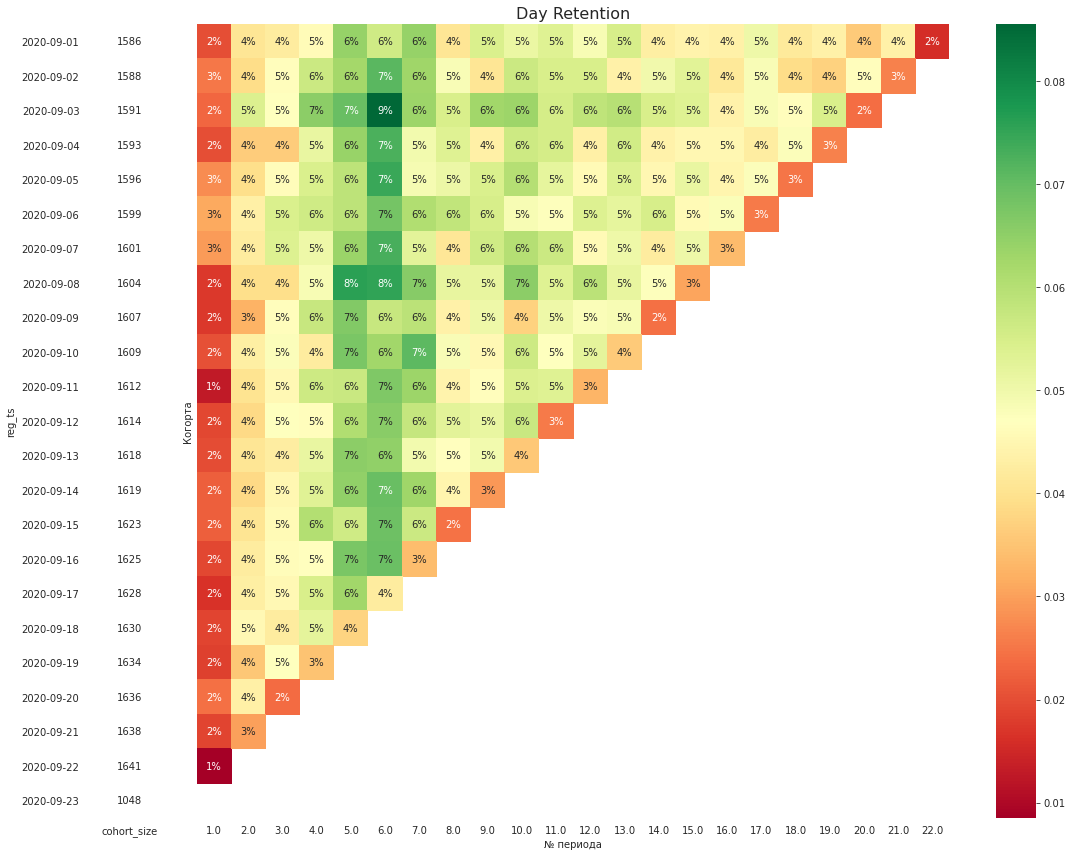

In [53]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix_without_0,
                mask=retention_matrix_without_0.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Day Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size_2020_Sep).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

Рассчитаем `средний Retention`, взвешенный по размерам когорт, за весь сентябрь 2020
(исключая нулевой день).

In [77]:
# Считаем средний процент для каждой когорты (игнорируя первый столбец)
mean_cohort = retention_matrix_without_0.mean(axis='columns').fillna(0)

In [79]:
# рассчитаем среднее количество вернувшихся людей в каждой когорте
mean_cohort = mean_cohort * cohort_size_2020_Sep

In [84]:
# рассчитаем взвешенный Retention за сентябрь
retention_mean = ( mean_cohort.sum() * 100 / cohort_size_2020_Sep.sum() ).round(2)
print(f"Средний взвешенный Retention за сентябрь 2020 года: {retention_mean} %")

Средний взвешенный Retention за сентябрь 2020 года: 4.21 %
